# MLP for Paragraph Embedding Inversion
**Goal:** Train an MLP that converts a single paragraph embedding `[1024]` into a sequence of token embeddings `[max_len, 1024]`

```
INPUT:  Single paragraph embedding  [1024]
          |
         MLP
          |
OUTPUT: Sequence of token embeddings [128, 1024]
```

---
## Section 1: Setup & Upload Dataset
Upload your `msmarco_token_sentence_embeddings.h5` file to Kaggle first.

Go to: **Add Data** (right panel) > **Upload** > select the `.h5` file

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
import time

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


---
## Section 2: Load & Explore the Dataset

In [4]:
# UPDATE THIS PATH based on where you uploaded the file on Kaggle
# If uploaded as a dataset: /kaggle/input/your-dataset-name/filename.h5
# If uploaded to working dir: /kaggle/working/filename.h5
H5_PATH = '/kaggle/input/datasets/subhavkumar/msmarco-token-paragraph-embeddings-dataset/msmarco_token_sentence_embeddings.h5'

# If file not found, try alternative paths
if not os.path.exists(H5_PATH):
    # Try common Kaggle paths
    possible = [
        '/kaggle/input/msmarco-token-sentence-embeddings/msmarco_token_sentence_embeddings.h5',
        '/kaggle/input/dataset/msmarco_token_sentence_embeddings.h5',
        '/kaggle/working/msmarco_token_sentence_embeddings.h5',
        'msmarco_token_sentence_embeddings.h5',
    ]
    for p in possible:
        if os.path.exists(p):
            H5_PATH = p
            break
    # List what's actually in /kaggle/input
    if not os.path.exists(H5_PATH):
        print('File not found! Here is what exists in /kaggle/input:')
        for root, dirs, files in os.walk('/kaggle/input'):
            for f in files:
                print(f'  {os.path.join(root, f)}')
        raise FileNotFoundError('Please update H5_PATH above')

print(f'Loading: {H5_PATH}')
print(f'File size: {os.path.getsize(H5_PATH) / (1024**3):.2f} GB')

Loading: /kaggle/input/datasets/subhavkumar/msmarco-token-paragraph-embeddings-dataset/msmarco_token_sentence_embeddings.h5
File size: 3.02 GB


In [5]:
# Open and explore
f = h5py.File(H5_PATH, 'r')

sentence_embs = f['sentence_embeddings']
token_embs = f['token_embeddings']

EMBED_DIM = np.array(sentence_embs[0]).shape[0]
NUM_SAMPLES = sentence_embs.shape[0]

print(f'Total samples: {NUM_SAMPLES}')
print(f'Embedding dimension: {EMBED_DIM}')

# Check token sequence lengths
print('\nScanning sequence lengths...')
seq_lengths = []
for i in range(NUM_SAMPLES):
    flat = np.array(token_embs[i])
    seq_lengths.append(flat.shape[0] // EMBED_DIM)

seq_lengths = np.array(seq_lengths)
print(f'\nSequence length stats:')
print(f'  Min:    {seq_lengths.min()}')
print(f'  Max:    {seq_lengths.max()}')
print(f'  Mean:   {seq_lengths.mean():.1f}')
print(f'  Median: {np.median(seq_lengths):.1f}')

f.close()

Total samples: 10000
Embedding dimension: 1024

Scanning sequence lengths...

Sequence length stats:
  Min:    4
  Max:    252
  Mean:   78.1
  Median: 69.0


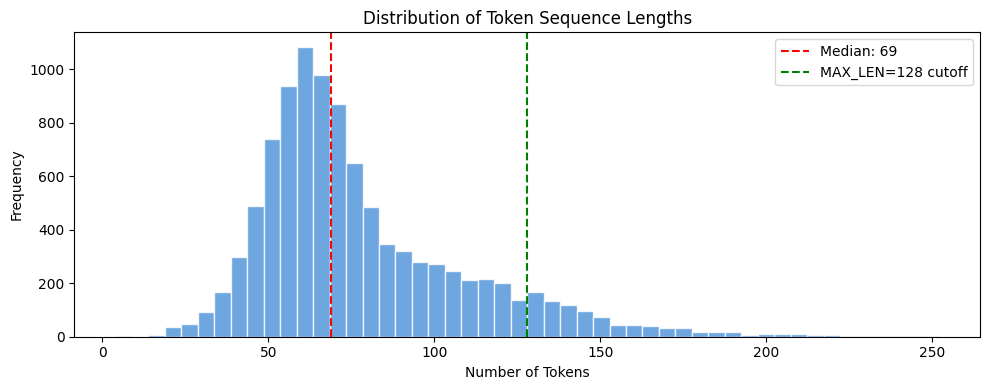

  MAX_LEN=64: keep 4091/10000 samples (40.9%)
  MAX_LEN=96: keep 7720/10000 samples (77.2%)
  MAX_LEN=128: keep 9136/10000 samples (91.4%)
  MAX_LEN=160: keep 9769/10000 samples (97.7%)
  MAX_LEN=256: keep 10000/10000 samples (100.0%)


In [6]:
# Visualize sequence length distribution
plt.figure(figsize=(10, 4))
plt.hist(seq_lengths, bins=50, color='#4a90d9', edgecolor='white', alpha=0.8)
plt.axvline(np.median(seq_lengths), color='red', linestyle='--', label=f'Median: {np.median(seq_lengths):.0f}')
plt.axvline(128, color='green', linestyle='--', label='MAX_LEN=128 cutoff')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.title('Distribution of Token Sequence Lengths')
plt.legend()
plt.tight_layout()
plt.show()

# How many samples would we keep with different MAX_LEN?
for ml in [64, 96, 128, 160, 256]:
    kept = (seq_lengths <= ml).sum()
    print(f'  MAX_LEN={ml}: keep {kept}/{NUM_SAMPLES} samples ({100*kept/NUM_SAMPLES:.1f}%)')

---
## Section 3: Configuration
Set your hyperparameters here.

In [7]:
# ============ HYPERPARAMETERS ============
MAX_LEN = 64          # max tokens (paragraphs longer than this are truncated)
BATCH_SIZE = 64         # batch size for training
EPOCHS = 30             # number of training epochs
LEARNING_RATE = 5e-4    # initial learning rate
TRAIN_SPLIT = 0.85      # 85% train, 15% test
HIDDEN_DIM = 2048       # MLP hidden layer size
# =========================================

OUTPUT_DIM = MAX_LEN * EMBED_DIM
print(f'Input dim:  {EMBED_DIM}')
print(f'Output dim: {MAX_LEN} x {EMBED_DIM} = {OUTPUT_DIM}')
print(f'Expansion ratio: {OUTPUT_DIM / EMBED_DIM:.0f}x')

Input dim:  1024
Output dim: 64 x 1024 = 65536
Expansion ratio: 64x


---
## Section 4: Create PyTorch Dataset

In [8]:
class EmbeddingInversionDataset(Dataset):
    """
    Dataset that loads (sentence_embedding, token_embeddings) pairs
    from the HDF5 file and pads/truncates token sequences to MAX_LEN.
    """
    def __init__(self, h5_path, max_len, embed_dim):
        self.h5_path = h5_path
        self.max_len = max_len
        self.embed_dim = embed_dim
        
        # Load ALL data into memory for speed
        print('Loading dataset into memory...')
        f = h5py.File(h5_path, 'r')
        
        self.X = []     # sentence embeddings [N, 1024]
        self.Y = []     # padded token embeddings [N, max_len, 1024]
        self.masks = [] # attention masks [N, max_len]
        self.lengths = [] # actual sequence lengths
        
        num_samples = f['sentence_embeddings'].shape[0]
        
        for i in range(num_samples):
            # Sentence embedding (input)
            sent_emb = np.array(f['sentence_embeddings'][i], dtype=np.float32)
            
            # Token embeddings (target) - reshape from flat to [num_tokens, dim]
            tok_flat = np.array(f['token_embeddings'][i], dtype=np.float32)
            num_tokens = tok_flat.shape[0] // embed_dim
            tok_embs = tok_flat.reshape(num_tokens, embed_dim)
            
            # Pad or truncate to max_len
            padded = np.zeros((max_len, embed_dim), dtype=np.float32)
            mask = np.zeros(max_len, dtype=np.float32)
            
            actual_len = min(num_tokens, max_len)
            padded[:actual_len] = tok_embs[:actual_len]
            mask[:actual_len] = 1.0
            
            self.X.append(sent_emb)
            self.Y.append(padded)
            self.masks.append(mask)
            self.lengths.append(actual_len)
            
            if (i + 1) % 2000 == 0:
                print(f'  Loaded {i+1}/{num_samples}')
        
        f.close()
        
        # Convert to tensors
        self.X = torch.tensor(np.array(self.X))         # [N, 1024]
        self.Y = torch.tensor(np.array(self.Y))         # [N, max_len, 1024]
        self.masks = torch.tensor(np.array(self.masks))  # [N, max_len]
        self.lengths = np.array(self.lengths)
        
        print(f'\nDataset loaded!')
        print(f'  X shape: {self.X.shape}')
        print(f'  Y shape: {self.Y.shape}')
        print(f'  Masks shape: {self.masks.shape}')
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.masks[idx]

In [9]:
# Create dataset
full_dataset = EmbeddingInversionDataset(H5_PATH, MAX_LEN, EMBED_DIM)

# Train/Test split
train_size = int(TRAIN_SPLIT * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

print(f'\nTrain samples: {len(train_dataset)}')
print(f'Test samples:  {len(test_dataset)}')

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick check
x_batch, y_batch, mask_batch = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  X batch: {x_batch.shape}')      # [64, 1024]
print(f'  Y batch: {y_batch.shape}')      # [64, 128, 1024]
print(f'  Mask batch: {mask_batch.shape}') # [64, 128]

Loading dataset into memory...
  Loaded 2000/10000
  Loaded 4000/10000
  Loaded 6000/10000
  Loaded 8000/10000
  Loaded 10000/10000

Dataset loaded!
  X shape: torch.Size([10000, 1024])
  Y shape: torch.Size([10000, 64, 1024])
  Masks shape: torch.Size([10000, 64])

Train samples: 8500
Test samples:  1500

Batch shapes:
  X batch: torch.Size([64, 1024])
  Y batch: torch.Size([64, 64, 1024])
  Mask batch: torch.Size([64, 64])


---
## Section 5: Define the MLP Model

In [24]:
class PositionalEmbeddingInverter(nn.Module):
    """
    MLP that predicts one token at a time using Positional Encodings.
    Input: Paragraph Embedding (1024) + Position Embedding (1024) concatenated -> (2048)
    Output: Single Token Embedding (1024)
    It does this in parallel for all 128 tokens.
    """
    def __init__(self, embed_dim=1024, max_len=128, hidden_dim=2048):
        super().__init__()
        
        self.embed_dim = embed_dim
        self.max_len = max_len
        
        # Learnable positional embeddings (one unique 1024-dim vector for each of the 128 positions)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        
        # The network now takes paragraph + position (1024 + 1024 = 2048)
        self.network = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, embed_dim) # Outputs just ONE token embedding
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # x is the paragraph embedding: [batch, 1024]
        batch_size = x.shape[0]
        
        # 1. Expand paragraph embedding to match the sequence length
        # Makes 128 copies of the paragraph embedding: [batch, 128, 1024]
        x_expanded = x.unsqueeze(1).expand(-1, self.max_len, -1)
        
        # 2. Create position numbers (0 to 127) and get their embeddings
        positions = torch.arange(self.max_len, device=x.device) # [128]
        # pos_embs: [batch, 128, 1024]
        pos_embs = self.pos_emb(positions).unsqueeze(0).expand(batch_size, -1, -1)
        
        # 3. Glue them together! [batch, 128, 2048]
        combined = torch.cat([x_expanded, pos_embs], dim=-1)
        
        # 4. Pass through MLP. Because PyTorch is smart, it applies the MLP 
        # independently to all 128 positions at the same time.
        # out: [batch, 128, 1024]
        out = self.network(combined)
        
        return out


# Create model
model = PositionalEmbeddingInverter(
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    hidden_dim=HIDDEN_DIM
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:')
print(model)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model size:           {total_params * 4 / (1024**2):.1f} MB (float32)')

Model architecture:
PositionalEmbeddingInverter(
  (pos_emb): Embedding(64, 1024)
  (network): Sequential(
    (0): Linear(in_features=2048, out_features=2048, bias=True)
    (1): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=2048, out_features=2048, bias=True)
    (5): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=2048, out_features=1024, bias=True)
  )
)

Total parameters:     10,564,608
Trainable parameters: 10,564,608
Model size:           40.3 MB (float32)


---
## Section 6: Define Loss Function
We use **Masked MSE Loss** — only compute loss on REAL tokens, not on padding positions.

In [11]:
def combined_loss(predicted, target, mask, input_embedding, alpha=1.0, beta=0.5, gamma=0.1):
    """
    Combined loss:
      alpha * (1 - token_cosine_sim)    ← main: each token direction correct
      beta  * (1 - paragraph_cosine_sim) ← regularizer: overall meaning preserved
      gamma * masked_MSE                ← small: prevent magnitude collapse
    """
    mask_expanded = mask.unsqueeze(-1)  # [batch, max_len, 1]
    
    # --- Token-level cosine loss ---
    token_cos = torch.nn.functional.cosine_similarity(predicted, target, dim=-1)  # [batch, max_len]
    masked_cos = (token_cos * mask).sum() / mask.sum()
    token_cos_loss = 1.0 - masked_cos
    
    # --- Paragraph-level cosine loss ---
    # Mean pool predicted token embeddings (only real tokens)
    pred_paragraph = (predicted * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1)  # [batch, 1024]
    para_cos = torch.nn.functional.cosine_similarity(pred_paragraph, input_embedding, dim=-1).mean()
    para_cos_loss = 1.0 - para_cos
    
    # --- Small MSE for magnitude ---
    sq_error = ((predicted - target) ** 2) * mask_expanded
    mse_loss = sq_error.sum() / (mask_expanded.sum() * predicted.shape[-1])
    
    total = alpha * token_cos_loss + beta * para_cos_loss + gamma * mse_loss
    
    return total, masked_cos, para_cos


def masked_cosine_similarity(predicted, target, mask):
    cos_sim = torch.nn.functional.cosine_similarity(predicted, target, dim=-1)
    masked_sim = (cos_sim * mask).sum() / mask.sum()
    return masked_sim


print('Combined loss defined!')
print('  alpha=1.0: token-level cosine (main)')
print('  beta=0.5:  paragraph-level cosine (regularizer)')
print('  gamma=0.1: MSE (magnitude preservation)')

Combined loss defined!
  alpha=1.0: token-level cosine (main)
  beta=0.5:  paragraph-level cosine (regularizer)
  gamma=0.1: MSE (magnitude preservation)


---
## Section 7: Training Loop

In [25]:
# Optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Training history
history = {
    'train_loss': [],
    'test_loss': [],
    'train_cos_sim': [],
    'test_cos_sim': [],
    'lr': []
}

best_test_loss = float('inf')
SAVE_PATH = '/kaggle/working/best_model.pt'

print(f'Starting training for {EPOCHS} epochs...')
print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')
print('='*70)

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    # ===== TRAINING =====
    model.train()
    train_loss_sum = 0
    train_cos_sum = 0
    train_batches = 0
    
    for x, y, mask in train_loader:
        x = x.to(device)       # [batch, 1024]
        y = y.to(device)       # [batch, 128, 1024]
        mask = mask.to(device) # [batch, 128]
        
        # Forward pass
        pred = model(x)        # [batch, 128, 1024]
        
        # Compute loss
        loss, tok_cos, para_cos = combined_loss(pred, y, mask, x)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Track metrics
        train_loss_sum += loss.item()
        with torch.no_grad():
            train_cos_sum += masked_cosine_similarity(pred, y, mask).item()
        train_batches += 1
    
    # ===== EVALUATION =====
    model.eval()
    test_loss_sum = 0
    test_cos_sum = 0
    test_batches = 0
    
    with torch.no_grad():
        for x, y, mask in test_loader:
            x = x.to(device)
            y = y.to(device)
            mask = mask.to(device)
            
            pred = model(x)
            loss, _, _ = combined_loss(pred, y, mask, x)
            
            test_loss_sum += loss.item()
            test_cos_sum += masked_cosine_similarity(pred, y, mask).item()
            test_batches += 1
    
    # Compute averages
    avg_train_loss = train_loss_sum / train_batches
    avg_test_loss = test_loss_sum / test_batches
    avg_train_cos = train_cos_sum / train_batches
    avg_test_cos = test_cos_sum / test_batches
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(avg_train_loss)
    history['test_loss'].append(avg_test_loss)
    history['train_cos_sim'].append(avg_train_cos)
    history['test_cos_sim'].append(avg_test_cos)
    history['lr'].append(current_lr)
    
    # Save best model
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_loss': best_test_loss,
            'config': {
                'embed_dim': EMBED_DIM,
                'max_len': MAX_LEN,
                'hidden_dim': HIDDEN_DIM,
            }
        }, SAVE_PATH)
        saved_flag = ' << SAVED BEST'
    else:
        saved_flag = ''
    
    # Step scheduler
    scheduler.step()
    
    # Print progress
    elapsed = time.time() - epoch_start
    print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
          f'Train Loss: {avg_train_loss:.6f} | '
          f'Test Loss: {avg_test_loss:.6f} | '
          f'Train CosSim: {avg_train_cos:.4f} | '
          f'Test CosSim: {avg_test_cos:.4f} | '
          f'LR: {current_lr:.2e} | '
          f'{elapsed:.1f}s{saved_flag}')

print('\n' + '='*70)
print(f'Training complete! Best test loss: {best_test_loss:.6f}')
print(f'Model saved to: {SAVE_PATH}')

Starting training for 30 epochs...
Train batches: 133, Test batches: 24
Epoch   1/30 | Train Loss: 1.694276 | Test Loss: 1.646514 | Train CosSim: 0.4622 | Test CosSim: 0.4804 | LR: 5.00e-04 | 13.4s << SAVED BEST
Epoch   2/30 | Train Loss: 1.586807 | Test Loss: 1.456871 | Train CosSim: 0.4993 | Test CosSim: 0.5422 | LR: 4.99e-04 | 13.9s << SAVED BEST
Epoch   3/30 | Train Loss: 1.379417 | Test Loss: 1.292137 | Train CosSim: 0.5646 | Test CosSim: 0.5935 | LR: 4.95e-04 | 14.2s << SAVED BEST
Epoch   4/30 | Train Loss: 1.279479 | Test Loss: 1.233028 | Train CosSim: 0.5952 | Test CosSim: 0.6115 | LR: 4.88e-04 | 13.6s << SAVED BEST
Epoch   5/30 | Train Loss: 1.236399 | Test Loss: 1.202658 | Train CosSim: 0.6084 | Test CosSim: 0.6206 | LR: 4.78e-04 | 13.2s << SAVED BEST
Epoch   6/30 | Train Loss: 1.210914 | Test Loss: 1.183255 | Train CosSim: 0.6161 | Test CosSim: 0.6265 | LR: 4.67e-04 | 13.1s << SAVED BEST
Epoch   7/30 | Train Loss: 1.193789 | Test Loss: 1.169733 | Train CosSim: 0.6213 | Test 

---
## Section 8: Plot Training History

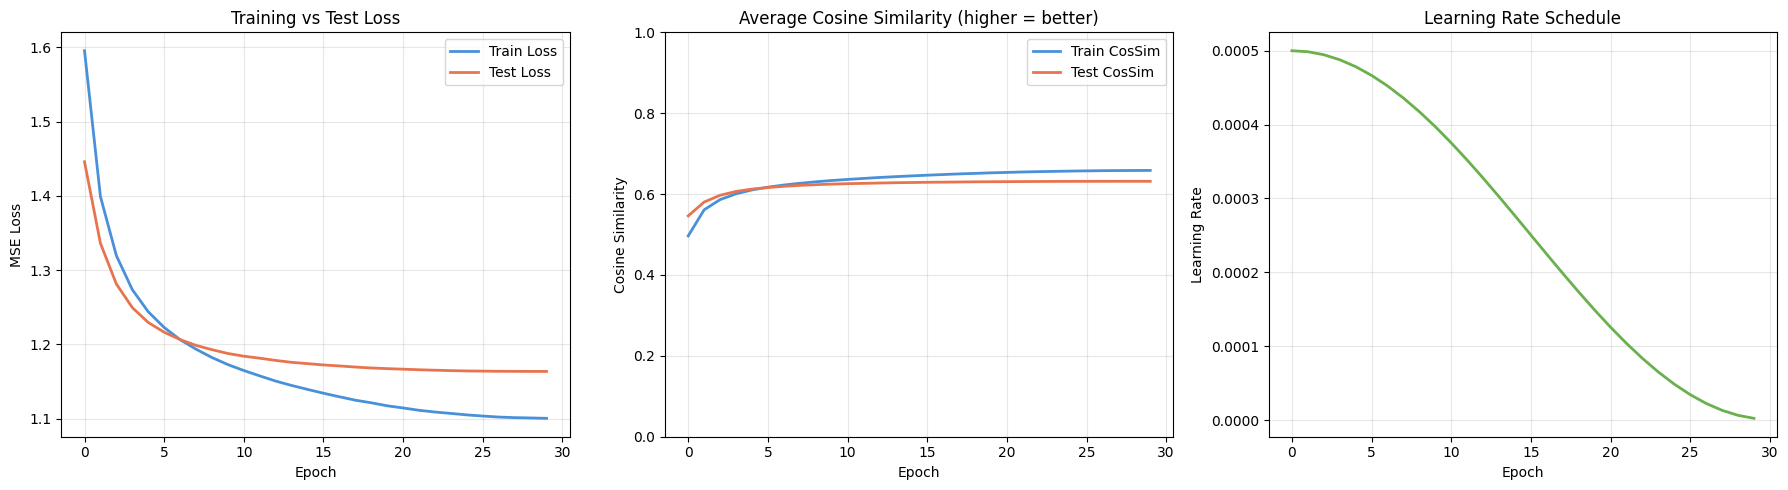

Final Train CosSim: 0.6585
Final Test CosSim:  0.6317


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='#4a90d9', linewidth=2)
axes[0].plot(history['test_loss'], label='Test Loss', color='#e8744f', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cosine Similarity
axes[1].plot(history['train_cos_sim'], label='Train CosSim', color='#4a90d9', linewidth=2)
axes[1].plot(history['test_cos_sim'], label='Test CosSim', color='#e8744f', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_title('Average Cosine Similarity (higher = better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

# Plot 3: Learning Rate
axes[2].plot(history['lr'], color='#6ab04c', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()

print(f'Final Train CosSim: {history["train_cos_sim"][-1]:.4f}')
print(f'Final Test CosSim:  {history["test_cos_sim"][-1]:.4f}')

---
## Section 9: Evaluate on Test Set (Unseen Data)

In [14]:
# Load best model
checkpoint = torch.load(SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded best model from epoch {checkpoint["epoch"]+1}')

# Evaluate on ALL test samples
all_cos_sims = []       # per-sample cosine similarity
all_mse_losses = []     # per-sample MSE
all_per_token_cos = []  # per-token cosine similarity

with torch.no_grad():
    for x, y, mask in test_loader:
        x = x.to(device)
        y = y.to(device)
        mask = mask.to(device)
        
        pred = model(x)
        
        # Per-token cosine similarity: [batch, max_len]
        per_token_cos = torch.nn.functional.cosine_similarity(pred, y, dim=-1)
        
        # Per-sample metrics
        for i in range(x.shape[0]):
            real_len = int(mask[i].sum().item())
            
            # Cosine sim on real tokens only
            sample_cos = per_token_cos[i, :real_len].mean().item()
            all_cos_sims.append(sample_cos)
            
            # MSE on real tokens only
            sample_mse = ((pred[i, :real_len] - y[i, :real_len]) ** 2).mean().item()
            all_mse_losses.append(sample_mse)
            
            # Per-token cosine sim
            all_per_token_cos.extend(per_token_cos[i, :real_len].cpu().tolist())

all_cos_sims = np.array(all_cos_sims)
all_mse_losses = np.array(all_mse_losses)
all_per_token_cos = np.array(all_per_token_cos)

print('='*60)
print('TEST SET EVALUATION RESULTS')
print('='*60)
print(f'\nPer-Sample Cosine Similarity:')
print(f'  Mean:   {all_cos_sims.mean():.4f}')
print(f'  Median: {np.median(all_cos_sims):.4f}')
print(f'  Std:    {all_cos_sims.std():.4f}')
print(f'  Min:    {all_cos_sims.min():.4f}')
print(f'  Max:    {all_cos_sims.max():.4f}')

print(f'\nPer-Sample MSE:')
print(f'  Mean:   {all_mse_losses.mean():.6f}')
print(f'  Median: {np.median(all_mse_losses):.6f}')

print(f'\nPer-Token Cosine Similarity:')
print(f'  Mean:   {all_per_token_cos.mean():.4f}')
print(f'  Total tokens evaluated: {len(all_per_token_cos):,}')

Loaded best model from epoch 30
TEST SET EVALUATION RESULTS

Per-Sample Cosine Similarity:
  Mean:   0.6330
  Median: 0.6335
  Std:    0.0414
  Min:    0.4562
  Max:    0.7933

Per-Sample MSE:
  Mean:   7.673861
  Median: 7.664590

Per-Token Cosine Similarity:
  Mean:   0.6320
  Total tokens evaluated: 88,908


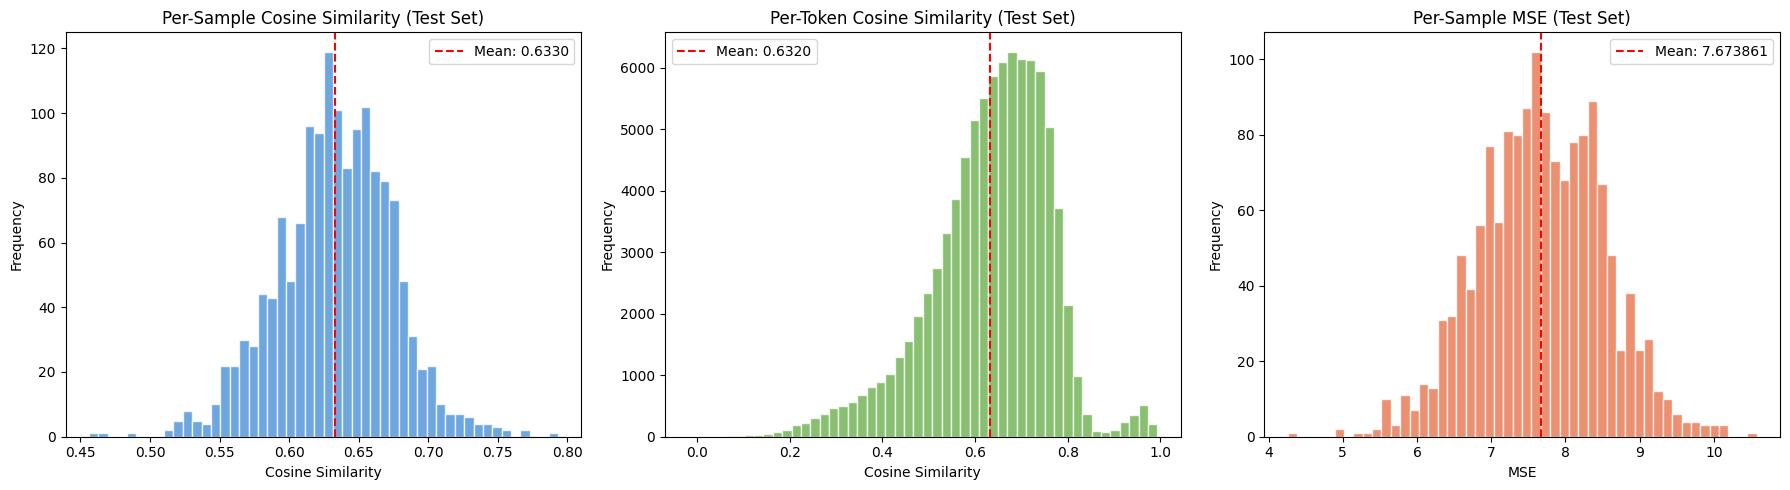

In [15]:
# Visualize test results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Per-sample cosine similarity distribution
axes[0].hist(all_cos_sims, bins=50, color='#4a90d9', edgecolor='white', alpha=0.8)
axes[0].axvline(all_cos_sims.mean(), color='red', linestyle='--', label=f'Mean: {all_cos_sims.mean():.4f}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Per-Sample Cosine Similarity (Test Set)')
axes[0].legend()

# Plot 2: Per-token cosine similarity distribution  
axes[1].hist(all_per_token_cos, bins=50, color='#6ab04c', edgecolor='white', alpha=0.8)
axes[1].axvline(all_per_token_cos.mean(), color='red', linestyle='--', label=f'Mean: {all_per_token_cos.mean():.4f}')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Per-Token Cosine Similarity (Test Set)')
axes[1].legend()

# Plot 3: MSE distribution
axes[2].hist(all_mse_losses, bins=50, color='#e8744f', edgecolor='white', alpha=0.8)
axes[2].axvline(all_mse_losses.mean(), color='red', linestyle='--', label=f'Mean: {all_mse_losses.mean():.6f}')
axes[2].set_xlabel('MSE')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Per-Sample MSE (Test Set)')
axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/test_evaluation.png', dpi=150)
plt.show()

---
## Section 10: Inspect Individual Predictions
Look at specific test samples to see how well the MLP reconstructs token embeddings.

In [16]:
# Pick 5 random test samples
np.random.seed(42)
test_indices = np.random.choice(len(test_dataset), size=5, replace=False)

model.eval()
with torch.no_grad():
    for idx in test_indices:
        x, y, mask = test_dataset[idx]
        x = x.unsqueeze(0).to(device)       # [1, 1024]
        y = y.unsqueeze(0).to(device)       # [1, 128, 1024]
        mask = mask.unsqueeze(0).to(device) # [1, 128]
        
        pred = model(x)  # [1, 128, 1024]
        
        real_len = int(mask.sum().item())
        
        # Per-token cosine similarity
        token_cos = torch.nn.functional.cosine_similarity(
            pred[0, :real_len], y[0, :real_len], dim=-1
        ).cpu().numpy()
        
        # Overall cosine similarity for this sample
        overall_cos = token_cos.mean()
        
        print(f'\nTest Sample (index {idx}):')
        print(f'  Sequence length: {real_len} tokens')
        print(f'  Overall cosine similarity: {overall_cos:.4f}')
        print(f'  Per-token cosine sim (first 10): {np.array2string(token_cos[:10], precision=3)}')
        print(f'  Min token sim: {token_cos.min():.4f}, Max: {token_cos.max():.4f}')


Test Sample (index 1116):
  Sequence length: 55 tokens
  Overall cosine similarity: 0.6727
  Per-token cosine sim (first 10): [0.98  0.786 0.83  0.857 0.808 0.58  0.848 0.466 0.725 0.817]
  Min token sim: 0.3053, Max: 0.9800

Test Sample (index 1368):
  Sequence length: 64 tokens
  Overall cosine similarity: 0.6693
  Per-token cosine sim (first 10): [0.964 0.534 0.525 0.622 0.6   0.506 0.535 0.483 0.621 0.613]
  Min token sim: 0.4297, Max: 0.9638

Test Sample (index 422):
  Sequence length: 54 tokens
  Overall cosine similarity: 0.6869
  Per-token cosine sim (first 10): [0.972 0.649 0.657 0.677 0.735 0.609 0.765 0.619 0.811 0.672]
  Min token sim: 0.2405, Max: 0.9720

Test Sample (index 413):
  Sequence length: 64 tokens
  Overall cosine similarity: 0.6009
  Per-token cosine sim (first 10): [0.933 0.661 0.5   0.56  0.472 0.501 0.571 0.528 0.391 0.4  ]
  Min token sim: 0.3580, Max: 0.9334

Test Sample (index 451):
  Sequence length: 64 tokens
  Overall cosine similarity: 0.6388
  Per-t

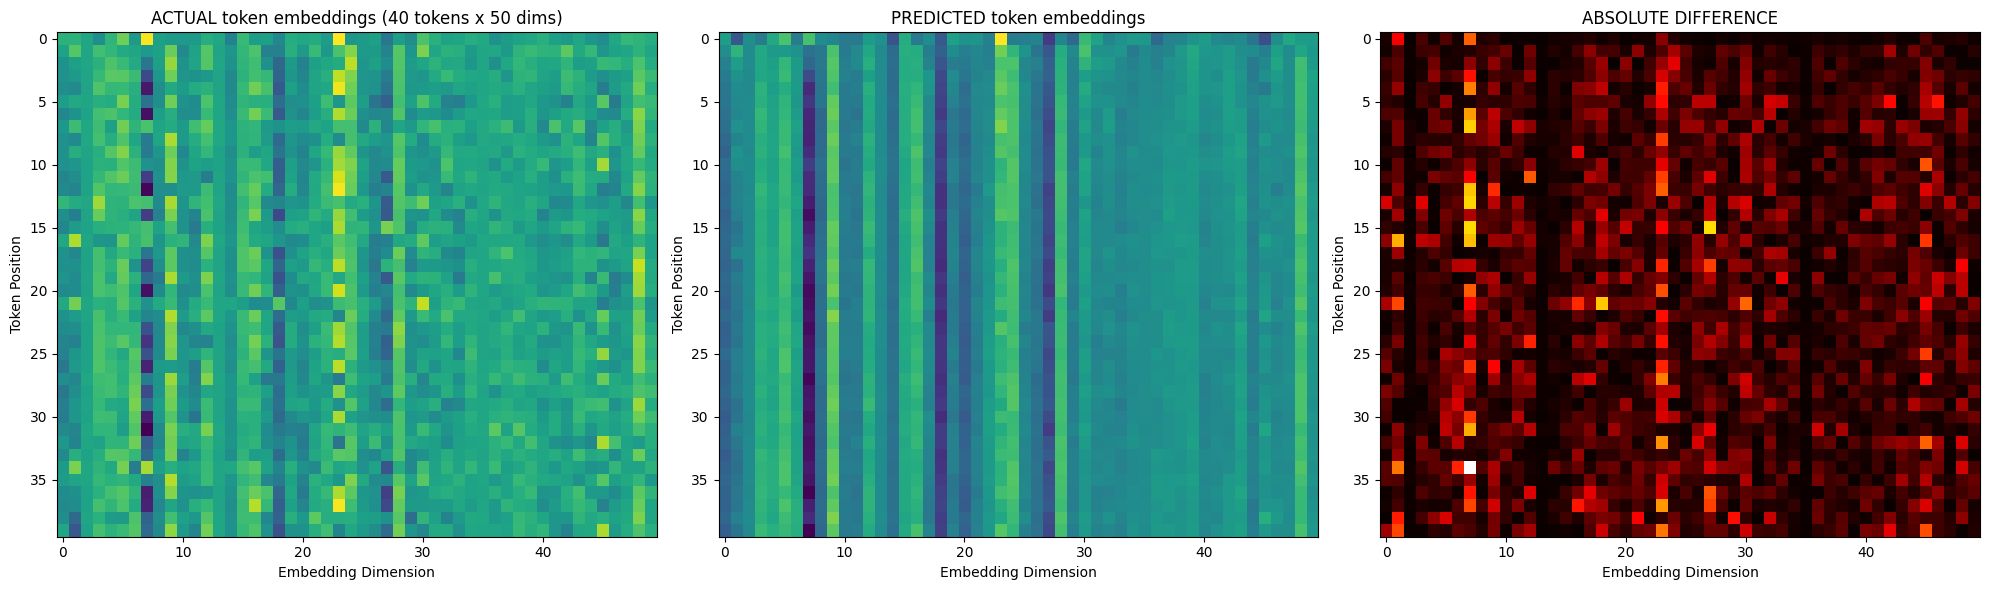

In [17]:
# Heatmap: predicted vs actual for one sample
sample_idx = test_indices[0]
x, y, mask = test_dataset[sample_idx]
x = x.unsqueeze(0).to(device)
y = y.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(x)

real_len = int(mask.sum().item())
real_len_show = min(real_len, 40)  # show max 40 tokens

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Show first 50 dims of first 40 tokens
show_dims = 50

axes[0].imshow(y[0, :real_len_show, :show_dims].cpu().numpy(), aspect='auto', cmap='viridis')
axes[0].set_title(f'ACTUAL token embeddings ({real_len_show} tokens x {show_dims} dims)')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Token Position')

axes[1].imshow(pred[0, :real_len_show, :show_dims].cpu().numpy(), aspect='auto', cmap='viridis')
axes[1].set_title(f'PREDICTED token embeddings')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Token Position')

diff = (pred[0, :real_len_show, :show_dims] - y[0, :real_len_show, :show_dims]).cpu().numpy()
axes[2].imshow(np.abs(diff), aspect='auto', cmap='hot')
axes[2].set_title(f'ABSOLUTE DIFFERENCE')
axes[2].set_xlabel('Embedding Dimension')
axes[2].set_ylabel('Token Position')

plt.tight_layout()
plt.savefig('/kaggle/working/prediction_comparison.png', dpi=150)
plt.show()

---
## Section 11: Save Everything

In [18]:
# Save training history
torch.save(history, '/kaggle/working/training_history.pt')

# Save test results
torch.save({
    'per_sample_cos_sim': all_cos_sims,
    'per_sample_mse': all_mse_losses,
    'per_token_cos_sim': all_per_token_cos,
}, '/kaggle/working/test_results.pt')

print('Saved files:')
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}') / (1024*1024)
    print(f'  {f}: {size:.1f} MB')

print('\n' + '='*60)
print('ALL DONE!')
print('='*60)
print(f'''
SUMMARY:
  Model: MLP ({total_params:,} parameters)
  Input:  paragraph embedding [1024]
  Output: token embedding sequence [{MAX_LEN}, 1024]
  
  Best test loss: {best_test_loss:.6f}
  Test cosine similarity: {all_cos_sims.mean():.4f}
  
  Files saved to /kaggle/working/:
    - best_model.pt (trained model weights)
    - training_history.pt (loss curves)
    - test_results.pt (evaluation metrics)
    - training_history.png (plots)
    - test_evaluation.png (test plots)
    - prediction_comparison.png (heatmaps)
''')

Saved files:
  training_history.png: 0.1 MB
  prediction_comparison.png: 0.1 MB
  .virtual_documents: 0.0 MB
  test_results.pt: 0.9 MB
  test_evaluation.png: 0.1 MB
  training_history.pt: 0.0 MB
  best_model.pt: 1620.9 MB

ALL DONE!

SUMMARY:
  Model: MLP (141,638,656 parameters)
  Input:  paragraph embedding [1024]
  Output: token embedding sequence [64, 1024]
  
  Best test loss: 1.163447
  Test cosine similarity: 0.6330
  
  Files saved to /kaggle/working/:
    - best_model.pt (trained model weights)
    - training_history.pt (loss curves)
    - test_results.pt (evaluation metrics)
    - training_history.png (plots)
    - test_evaluation.png (test plots)
    - prediction_comparison.png (heatmaps)



In [26]:
# --- Section 12: Decode Embeddings to Text ---
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F
import torch
import numpy as np

# Define device just to be safe
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Exact model name you are using
DECODER_MODEL_NAME = "Qwen/Qwen3-0.6B" 

print(f"Loading {DECODER_MODEL_NAME} to get vocabulary...")

# Load tokenizer and model for Qwen
tokenizer = AutoTokenizer.from_pretrained(DECODER_MODEL_NAME, trust_remote_code=True)
vocab_model = AutoModel.from_pretrained(DECODER_MODEL_NAME, trust_remote_code=True).to(device)

# THIS IS THE FIX: Safely get the input embedding matrix for the Qwen architecture
vocab_embeddings = vocab_model.get_input_embeddings().weight.detach().float()

print(f"Vocabulary matrix shape: {vocab_embeddings.shape}")
if vocab_embeddings.shape[1] != 1024:
    print(f"WARNING: The model {DECODER_MODEL_NAME} has {vocab_embeddings.shape[1]} dimensions, but your dataset has 1024!")

def decode_embeddings_to_text(embeddings_seq, mask):
    """
    Maps 1024-dim token embeddings back to vocabulary words using Cosine Similarity.
    """
    real_len = int(mask.sum().item())
    valid_embeddings = embeddings_seq[:real_len] # [real_len, 1024]
    
    # Normalize for cosine similarity
    valid_norm = F.normalize(valid_embeddings, p=2, dim=1)
    vocab_norm = F.normalize(vocab_embeddings, p=2, dim=1)
    
    # Matrix multiplication gives cosine similarity
    similarity_scores = torch.matmul(valid_norm, vocab_norm.T) # [real_len, vocab_size]
    
    # Get the token ID with the highest similarity for each position
    best_token_ids = torch.argmax(similarity_scores, dim=1)
    
    # Decode token IDs to text
    decoded_text = tokenizer.decode(best_token_ids.cpu().tolist(), skip_special_tokens=True)
    return decoded_text

print("\n" + "="*70)
print("ACTUAL VS PREDICTED SENTENCES")
print("="*70)

# Pick 3 random test samples
np.random.seed(42) 
test_indices = np.random.choice(len(test_dataset), size=3, replace=False)

model.eval()
with torch.no_grad():
    for idx in test_indices:
        x, y, mask = test_dataset[idx]
        x = x.unsqueeze(0).to(device)
        y = y.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)
        
        # Get MLP prediction
        pred = model(x) # [1, max_len, 1024]
        
        # Decode the ACTUAL embeddings (Target)
        actual_text = decode_embeddings_to_text(y[0], mask[0])
        
        # Decode the PREDICTED embeddings (MLP Output)
        predicted_text = decode_embeddings_to_text(pred[0], mask[0])
        
        print(f"\nSample {idx}:")
        print(f"ACTUAL:    {actual_text}")
        print(f"PREDICTED: {predicted_text}")
        print("-" * 70)

Loading Qwen/Qwen3-0.6B to get vocabulary...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3Model LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vocabulary matrix shape: torch.Size([151936, 1024])

ACTUAL VS PREDICTED SENTENCES

Sample 1116:
ACTUAL:    : F F a vital of F vitamin B B is a B-made synthetic manbi) B of B low, is B in the or is to the foods and Folic is the B name for fol B occurring folate and in fol and fololic acid F F B
PREDICTED: : is is B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B B
----------------------------------------------------------------------

Sample 1368:
ACTUAL:    : the is the longer more detailed: The answer priest the the priest or he is not a vest or the of the is the vest that vest priest types denotes are on the is the the in the origins and clothing clothing code for the time mass forms AD vest vest of the old and the less little不变 the is changes
PREDICTED: : the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the th